# CS 515 - 3D Gaussian Splatting vs Mip-Splatting
### Production Notebook | Papers 1 & 2

| | |
|---|---|
| **Paper 1** | 3D Gaussian Splatting - Kerbl et al., SIGGRAPH 2023 |
| **Paper 2** | Mip-Splatting - Yu et al., CVPR 2024 |

---
### Drive Folder Structure
```
CS515_Project/
├── code/gaussian-splatting/
├── datasets/paper_data/garden/
├── datasets/own_data/my_scene/
│   ├── input/           <- extracted frames
│   └── video.MOV
├── models/3dgs_baseline/<scene>/
├── models/mip_splatting/<scene>/
├── renders/3dgs_baseline/<scene>/scale_Xx/
├── renders/mip_splatting/<scene>/scale_Xx/
└── renders/comparison/<scene>/
```
---
**Runtime -> A100 GPU + High RAM**
Resolution guide: A100=1 | L4/V100=2 | T4=4

## CELL 0 - Verify GPU

In [1]:
# -- CELL 0: Verify GPU --
import subprocess, torch
print(subprocess.run(['nvidia-smi'], capture_output=True, text=True).stdout)
print(f'PyTorch : {torch.__version__}')
print(f'CUDA    : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    vram = torch.cuda.get_device_properties(0).total_memory/1e9
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
    print(f'VRAM    : {vram:.1f} GB')
    if vram > 35: print('OK A100 - use RESOLUTION=1')
    elif vram > 20: print('OK L4/V100 - use RESOLUTION=2')
    else: print('WARNING T4 - use RESOLUTION=4')


Mon Apr 27 22:14:42 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   31C    P0             56W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

## CELL 1 - Mount Drive & Create Folders

In [2]:
# -- CELL 1: Mount Drive & Create Folders --
from google.colab import drive
import os
drive.mount('/content/drive')

PROJECT_ROOT = '/content/drive/MyDrive/CS515_Project'

for d in [
    f'{PROJECT_ROOT}/code',
    f'{PROJECT_ROOT}/datasets/paper_data',
    f'{PROJECT_ROOT}/datasets/own_data',
    f'{PROJECT_ROOT}/models/3dgs_baseline',
    f'{PROJECT_ROOT}/models/mip_splatting',
    f'{PROJECT_ROOT}/renders/3dgs_baseline',
    f'{PROJECT_ROOT}/renders/mip_splatting',
    f'{PROJECT_ROOT}/renders/comparison',
]:
    os.makedirs(d, exist_ok=True)
    print(f'OK {d}')
print('All folders ready!')


Mounted at /content/drive
OK /content/drive/MyDrive/CS515_Project/code
OK /content/drive/MyDrive/CS515_Project/datasets/paper_data
OK /content/drive/MyDrive/CS515_Project/datasets/own_data
OK /content/drive/MyDrive/CS515_Project/models/3dgs_baseline
OK /content/drive/MyDrive/CS515_Project/models/mip_splatting
OK /content/drive/MyDrive/CS515_Project/renders/3dgs_baseline
OK /content/drive/MyDrive/CS515_Project/renders/mip_splatting
OK /content/drive/MyDrive/CS515_Project/renders/comparison
All folders ready!


## CELL 2 - Clone Repo (once, cached on Drive)

In [3]:
# -- CELL 2: Clone Repo --
import os
REPO_DIR = f'{PROJECT_ROOT}/code/gaussian-splatting'
if not os.path.exists(REPO_DIR):
    print('Cloning...')
    !git clone https://github.com/graphdeco-inria/gaussian-splatting --recursive {REPO_DIR}
    print('OK Cloned.')
else:
    print('OK Already on Drive. Skipping.')
if not os.path.exists('/content/gaussian-splatting'):
    os.symlink(REPO_DIR, '/content/gaussian-splatting')
    print('OK Symlinked.')
%cd /content/gaussian-splatting
!git log --oneline -3


OK Already on Drive. Skipping.
OK Symlinked.
/content/drive/MyDrive/CS515_Project/code/gaussian-splatting
54c035f (HEAD -> main, origin/main, origin/HEAD) fix submodule name in environment.yml
3dc0b75 fix training report, add missing dependency
9e1c2c6 fix asset name in results.md


## CELL 3 - Install Dependencies
Must re-run every session (~5 min). Installs from local copy to avoid Drive disconnection errors.

In [4]:
# -- CELL 3: Install Dependencies (every session) --
import os
os.chdir('/content')
if not os.path.exists('/content/submodules'):
    !cp -r /content/gaussian-splatting/submodules /content/submodules
    print('OK Submodules copied locally')
!pip install /content/submodules/diff-gaussian-rasterization -q
!pip install /content/submodules/simple-knn -q
!pip install plyfile tqdm -q
import torch
try:
    from diff_gaussian_rasterization import GaussianRasterizer
    print('OK diff-gaussian-rasterization')
except ImportError:
    print('FAILED diff-gaussian-rasterization - re-run this cell')
try:
    from simple_knn._C import distCUDA2
    print('OK simple-knn')
except ImportError:
    print('FAILED simple-knn - re-run this cell')
print(f'PyTorch {torch.__version__} | CUDA {torch.version.cuda}')


OK Submodules copied locally
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 3.9 MB/s eta 0:00:00
OK diff-gaussian-rasterization
OK simple-knn
PyTorch 2.10.0+cu128 | CUDA 12.8


## CELL 4 - Download MipNeRF360 Dataset (Garden Scene)

In [5]:
# -- CELL 4: Download MipNeRF360 Dataset --
import os
SCENE     = 'garden'
SCENE_DIR = f'{PROJECT_ROOT}/datasets/paper_data/{SCENE}'
if not os.path.exists(SCENE_DIR):
    print('Downloading garden scene (~11GB)...')
    !wget -q --show-progress http://storage.googleapis.com/gresearch/refraw360/360_v2.zip -O /tmp/360.zip
    !unzip -q /tmp/360.zip -d /tmp/360d/
    !mv /tmp/360d/{SCENE} {SCENE_DIR}
    !rm -rf /tmp/360.zip /tmp/360d
    print(f'OK {SCENE_DIR}')
else:
    print('OK Already exists. Skipping.')
os.makedirs('/content/data', exist_ok=True)
if not os.path.exists(f'/content/data/{SCENE}'):
    os.symlink(SCENE_DIR, f'/content/data/{SCENE}')
print('Contents:', os.listdir(SCENE_DIR))


OK Already exists. Skipping.
Contents: ['poses_bounds.npy', 'sparse', 'images_8', 'images_4', 'images_2', 'images']


## CELL 5 - Configuration
Set RESOLUTION=1 on A100 | =2 on L4/V100 | =4 on T4

In [6]:
# -- CELL 5: Configuration --
SCENE      = 'garden'
ITERATIONS = 7000
RESOLUTION = 1

import os
SOURCE_DIR  = f'/content/data/{SCENE}'
MODEL_3DGS  = f'{PROJECT_ROOT}/models/3dgs_baseline/{SCENE}'
MODEL_MIP   = f'{PROJECT_ROOT}/models/mip_splatting/{SCENE}'
RENDER_3DGS = f'{PROJECT_ROOT}/renders/3dgs_baseline/{SCENE}'
RENDER_MIP  = f'{PROJECT_ROOT}/renders/mip_splatting/{SCENE}'
COMPARE_DIR = f'{PROJECT_ROOT}/renders/comparison/{SCENE}'

for d in [MODEL_3DGS,MODEL_MIP,RENDER_3DGS,RENDER_MIP,COMPARE_DIR]:
    os.makedirs(d, exist_ok=True)
print(f'Scene={SCENE} | Iters={ITERATIONS} | Res=1/{RESOLUTION}')


Scene=garden | Iters=7000 | Res=1/1


## CELL 6 - Train 3DGS
~15 min at 7k on A100. Skips if already trained.

In [7]:
# -- CELL 6: Train Vanilla 3DGS --
import os, time
%cd /content/gaussian-splatting
ckpt = f'{MODEL_3DGS}/point_cloud/iteration_{ITERATIONS}/point_cloud.ply'
if os.path.exists(ckpt):
    print(f'OK Already trained at {ITERATIONS} iters. Skipping.')
else:
    print(f'Training 3DGS {ITERATIONS} iters...')
    t = time.time()
    !python train.py -s {SOURCE_DIR} -m {MODEL_3DGS} --iterations {ITERATIONS} -r {RESOLUTION} --eval
    print(f'OK Done in {(time.time()-t)/60:.1f} min')


/content/drive/MyDrive/CS515_Project/code/gaussian-splatting
OK Already trained at 7000 iters. Skipping.


## CELL 7 - Train Mip-Splatting
~15 min at 7k on A100. Skips if already trained.

In [8]:
# -- CELL 7: Train Mip-Splatting --
import os, time
%cd /content/gaussian-splatting
ckpt = f'{MODEL_MIP}/point_cloud/iteration_{ITERATIONS}/point_cloud.ply'
if os.path.exists(ckpt):
    print(f'OK Already trained at {ITERATIONS} iters. Skipping.')
else:
    print(f'Training Mip-Splatting {ITERATIONS} iters...')
    t = time.time()
    !python train.py -s {SOURCE_DIR} -m {MODEL_MIP} --iterations {ITERATIONS} -r {RESOLUTION} --antialiasing --eval
    print(f'OK Done in {(time.time()-t)/60:.1f} min')


/content/drive/MyDrive/CS515_Project/code/gaussian-splatting
OK Already trained at 7000 iters. Skipping.


## CELL 8 - Render 3DGS at Multiple Scales
Uses subprocess + memory flush. Saves to scale_Xx folders.

In [9]:
# -- CELL 8: Render 3DGS --
import os, torch, subprocess, gc
os.chdir('/content')

RENDER_SCALES = [2, 4, 8]

for scale in RENDER_SCALES:
    out_dir = f'{RENDER_3DGS}/scale_{scale}x'
    os.makedirs(out_dir, exist_ok=True)
    torch.cuda.empty_cache(); gc.collect()
    free = torch.cuda.mem_get_info()[0]/1e9
    print(f'Rendering 3DGS 1/{scale} | VRAM free: {free:.1f}GB')

    result = subprocess.run([
        'python', '/content/gaussian-splatting/render.py',
        '-m', MODEL_3DGS,
        '-s', f'{PROJECT_ROOT}/datasets/paper_data/{SCENE}',
        '--iteration', str(ITERATIONS),
        '-r', str(scale),
        '--skip_train', '--quiet'
    ], capture_output=True, text=True, cwd='/content/gaussian-splatting')

    if result.returncode == 0:
        !cp -r {MODEL_3DGS}/test/ours_{ITERATIONS}/renders/*.png {out_dir}/ 2>/dev/null || true
        n = len([f for f in os.listdir(out_dir) if f.endswith('.png')])
        print(f'  OK {n} frames saved')
    else:
        print(f'  ERROR: {result.stderr[-400:]}')
print('All 3DGS renders done.')


Rendering 3DGS 1/2 | VRAM free: 84.6GB
  OK 24 frames saved
Rendering 3DGS 1/4 | VRAM free: 84.6GB
  OK 24 frames saved
Rendering 3DGS 1/8 | VRAM free: 84.6GB
  OK 24 frames saved
All 3DGS renders done.


## CELL 9 - Render Mip-Splatting at Multiple Scales

In [10]:
# -- CELL 9: Render Mip-Splatting --
import os, torch, subprocess, gc
os.chdir('/content')

RENDER_SCALES = [2, 4, 8]

for scale in RENDER_SCALES:
    out_dir = f'{RENDER_MIP}/scale_{scale}x'
    os.makedirs(out_dir, exist_ok=True)
    torch.cuda.empty_cache(); gc.collect()
    free = torch.cuda.mem_get_info()[0]/1e9
    print(f'Rendering Mip-Splatting 1/{scale} | VRAM free: {free:.1f}GB')

    result = subprocess.run([
        'python', '/content/gaussian-splatting/render.py',
        '-m', MODEL_MIP,
        '-s', f'{PROJECT_ROOT}/datasets/paper_data/{SCENE}',
        '--iteration', str(ITERATIONS),
        '-r', str(scale),
        '--antialiasing', '--skip_train', '--quiet'
    ], capture_output=True, text=True, cwd='/content/gaussian-splatting')

    if result.returncode == 0:
        !cp -r {MODEL_MIP}/test/ours_{ITERATIONS}/renders/*.png {out_dir}/ 2>/dev/null || true
        n = len([f for f in os.listdir(out_dir) if f.endswith('.png')])
        print(f'  OK {n} frames saved')
    else:
        print(f'  ERROR: {result.stderr[-400:]}')
print('All Mip-Splatting renders done.')


Rendering Mip-Splatting 1/2 | VRAM free: 84.6GB
  OK 24 frames saved
Rendering Mip-Splatting 1/4 | VRAM free: 84.6GB
  OK 24 frames saved
Rendering Mip-Splatting 1/8 | VRAM free: 84.6GB
  OK 24 frames saved
All Mip-Splatting renders done.


## CELL 10 - Metrics (PSNR / SSIM / LPIPS)

In [11]:
# -- CELL 10: Evaluate Metrics --
import json, os
%cd /content/gaussian-splatting
!python metrics.py -m {MODEL_3DGS}
!python metrics.py -m {MODEL_MIP}

def gm(d):
    p = f'{d}/results.json'
    return json.load(open(p)) if os.path.exists(p) else None

m3=gm(MODEL_3DGS); mm=gm(MODEL_MIP); key=f'ours_{ITERATIONS}'
print('\n' + '-'*55)
print(f'  {"Metric":<12} {"3DGS":>16} {"Mip-Splatting":>16}')
print('-'*55)
if m3 and mm:
    for met in ['PSNR','SSIM','LPIPS']:
        v3=m3.get(key,{}).get(met,'N/A'); vm=mm.get(key,{}).get(met,'N/A')
        if isinstance(v3,float): v3=f'{v3:.4f}'
        if isinstance(vm,float): vm=f'{vm:.4f}'
        print(f'  {met:<12} {v3:>16} {vm:>16}')
print('-'*55)
print('PSNR/SSIM higher=better | LPIPS lower=better')


/content/drive/MyDrive/CS515_Project/code/gaussian-splatting

Scene: /content/drive/MyDrive/CS515_Project/models/3dgs_baseline/garden
Method: ours_7000
Metric evaluation progress:   0% 0/24 [00:00<?, ?it/s]Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth

  0% 0.00/528M [00:00<?, ?B/s]
  3% 17.8M/528M [00:00<00:02, 186MB/s]
  7% 39.0M/528M [00:00<00:02, 207MB/s]
 11% 60.1M/528M [00:00<00:02, 213MB/s]
 15% 81.4M/528M [00:00<00:02, 217MB/s]
 19% 103M/528M [00:00<00:02, 218MB/s] 
 23% 124M/528M [00:00<00:01, 219MB/s]
 27% 145M/528M [00:00<00:01, 220MB/s]
 31% 166M/528M [00:00<00:01, 220MB/s]
 35% 187M/528M [00:00<00:01, 220MB/s]
 39% 208M/528M [00:01<00:01, 219MB/s]
 43% 229M/528M [00:01<00:01, 220MB/s]
 47% 250M/528M [00:01<00:01, 220MB/s]
 51% 272M/528M [00:01<00:01, 220MB/s]
 55% 293M/528M [00:01<00:01, 221MB/s]
 59% 314M/528M [00:01<00:01, 221MB/s]
 63% 335M/528M [00:01<00:00, 220MB/s]
 67% 356M/528M [00:01<

## CELL 11 - Side-by-Side Comparison Figure

In [12]:
# -- CELL 11: Visual Comparison --
import matplotlib.pyplot as plt, matplotlib.image as mpimg
from glob import glob

SCALES, N = [2, 4, 8], 3
fig, axes = plt.subplots(len(SCALES), N*2, figsize=(N*7, len(SCALES)*3.5))
fig.suptitle(
    f'3DGS vs Mip-Splatting | {SCENE.title()} | {ITERATIONS} iters\n'
    f'Left: 3DGS Baseline | Right: Mip-Splatting',
    fontsize=13, fontweight='bold', y=1.01
)
for r,sc in enumerate(SCALES):
    i3 = sorted(glob(f'{RENDER_3DGS}/scale_{sc}x/*.png'))[:N]
    im = sorted(glob(f'{RENDER_MIP}/scale_{sc}x/*.png'))[:N]
    for c in range(N):
        a3=axes[r][c*2]; am=axes[r][c*2+1]
        if c<len(i3): a3.imshow(mpimg.imread(i3[c]))
        if c<len(im):  am.imshow(mpimg.imread(im[c]))
        a3.set_title(f'3DGS 1/{sc}',fontsize=8,color='#c0392b'); a3.axis('off')
        am.set_title(f'Mip 1/{sc}', fontsize=8,color='#27ae60'); am.axis('off')
plt.tight_layout()
out = f'{COMPARE_DIR}/comparison_{SCENE}_{ITERATIONS}iter.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
print(f'OK Saved: {out}')
plt.show()


Output hidden; open in https://colab.research.google.com to view.

## CELL 12 - Zoom Crop: Aliasing Detail
Run first to see full frame, then tune CROP_BOXES to detail-rich regions.

Image size: 1297x840


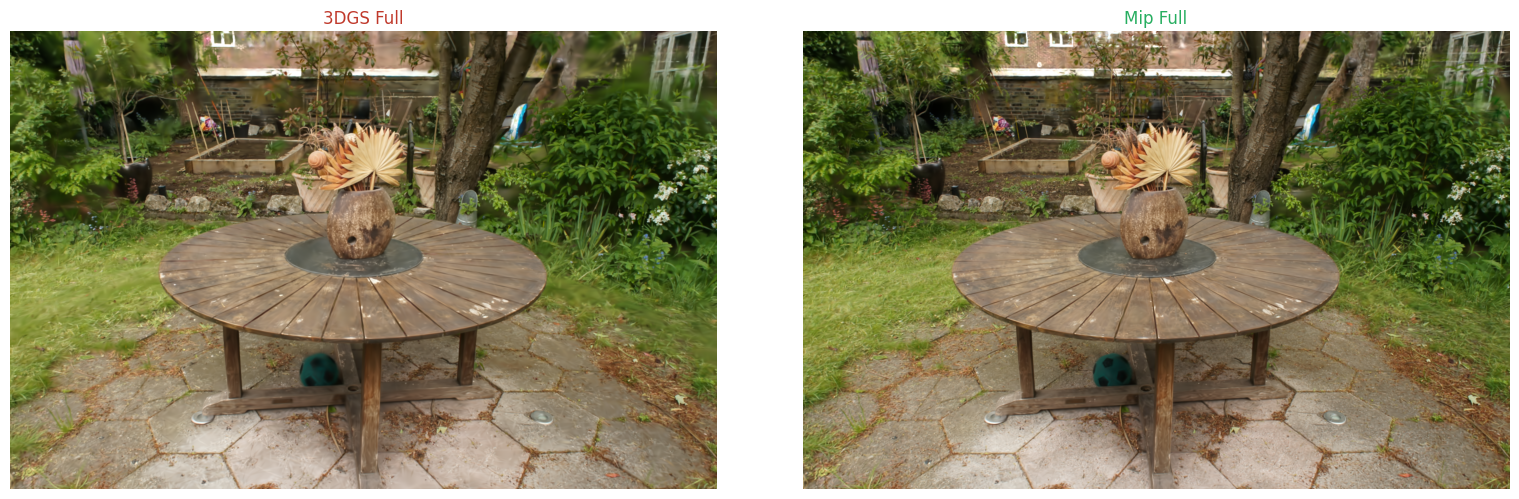

Tune CROP_BOXES below then run Cell 12b


In [13]:
# -- CELL 12: Zoom Crop Comparison --
from PIL import Image
import matplotlib.pyplot as plt, matplotlib.patches as patches
from glob import glob
import numpy as np

SCALE = 4
FRAME = 5

imgs3 = sorted(glob(f'{RENDER_3DGS}/scale_{SCALE}x/*.png'))
imgsm = sorted(glob(f'{RENDER_MIP}/scale_{SCALE}x/*.png'))

if not imgs3:
    print(f'No renders at scale {SCALE}x - run Cells 8 & 9 first')
else:
    img3 = Image.open(imgs3[FRAME])
    imgm = Image.open(imgsm[FRAME])
    w, h = img3.size
    print(f'Image size: {w}x{h}')

    fig, axes = plt.subplots(1,2,figsize=(16,5))
    axes[0].imshow(np.array(img3)); axes[0].set_title('3DGS Full',color='#c0392b'); axes[0].axis('off')
    axes[1].imshow(np.array(imgm)); axes[1].set_title('Mip Full',color='#27ae60');  axes[1].axis('off')
    plt.tight_layout(); plt.show()
    print('Tune CROP_BOXES below then run Cell 12b')


In [14]:
# -- CELL 12b: Detailed Crop Comparison --
CROP_BOXES = {
    'Foliage':  (100, 50,  450, 300),
    'Center':   (300, 200, 650, 450),
    'Edges':    (500, 100, 850, 350),
}

from PIL import Image
import matplotlib.pyplot as plt, matplotlib.patches as patches
from glob import glob
import numpy as np, os

SCALE, FRAME = 4, 5
imgs3 = sorted(glob(f'{RENDER_3DGS}/scale_{SCALE}x/*.png'))
imgsm = sorted(glob(f'{RENDER_MIP}/scale_{SCALE}x/*.png'))
img3  = Image.open(imgs3[FRAME])
imgm  = Image.open(imgsm[FRAME])

fig, axes = plt.subplots(len(CROP_BOXES), 4, figsize=(20, len(CROP_BOXES)*4))
fig.suptitle(
    f'3DGS vs Mip-Splatting | Zoom Crop | Scale 1/{SCALE}\n'
    f'Col 1-2: 3DGS (full+crop) | Col 3: Mip crop | Col 4: Difference heatmap',
    fontsize=12, fontweight='bold', y=1.01
)

for row, (name, box) in enumerate(CROP_BOXES.items()):
    c3  = np.array(img3.crop(box))
    cm  = np.array(imgm.crop(box))
    diff = np.abs(c3.astype(float)-cm.astype(float))
    diff_norm = (diff/(diff.max()+1e-8)*255).astype(np.uint8)

    axes[row][0].imshow(np.array(img3))
    axes[row][0].add_patch(patches.Rectangle(
        (box[0],box[1]),box[2]-box[0],box[3]-box[1],
        lw=2,edgecolor='#c0392b',facecolor='none'))
    axes[row][0].set_title(f'3DGS Full - {name}',fontsize=9,color='#c0392b'); axes[row][0].axis('off')
    axes[row][1].imshow(c3);  axes[row][1].set_title('3DGS Crop',fontsize=9,color='#c0392b'); axes[row][1].axis('off')
    axes[row][2].imshow(cm);  axes[row][2].set_title('Mip Crop', fontsize=9,color='#27ae60'); axes[row][2].axis('off')
    axes[row][3].imshow(diff_norm,cmap='hot'); axes[row][3].set_title('Diff Heatmap',fontsize=9,color='purple'); axes[row][3].axis('off')

plt.tight_layout()
out = f'{COMPARE_DIR}/zoom_crop_{SCENE}_{ITERATIONS}iter_scale{SCALE}.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
print(f'OK Saved: {out}')
plt.show()


Output hidden; open in https://colab.research.google.com to view.

---
## OWN DATA PIPELINE
### CELL 13 to 13f

**Upload** `video.MOV` to Drive at:
`CS515_Project/datasets/own_data/my_scene/video.MOV`

In [15]:
# -- CELL 13: Own Data Config --
import os

YOUR_SCENE     = 'my_scene'
OWN_ITERATIONS = 10000

OWN_SCENE_DIR = f'{PROJECT_ROOT}/datasets/own_data/{YOUR_SCENE}'
OWN_INPUT_DIR = f'{OWN_SCENE_DIR}/input'
OWN_MDL_3DGS  = f'{PROJECT_ROOT}/models/3dgs_baseline/{YOUR_SCENE}'
OWN_MDL_MIP   = f'{PROJECT_ROOT}/models/mip_splatting/{YOUR_SCENE}'

OWN_RND_3DGS  = f'{PROJECT_ROOT}/renders/3dgs_baseline/{YOUR_SCENE}_{OWN_ITERATIONS}iter'
OWN_RND_MIP   = f'{PROJECT_ROOT}/renders/mip_splatting/{YOUR_SCENE}_{OWN_ITERATIONS}iter'
OWN_COMP_DIR  = f'{PROJECT_ROOT}/renders/comparison/{YOUR_SCENE}_{OWN_ITERATIONS}iter'

for d in [OWN_INPUT_DIR,OWN_MDL_3DGS,OWN_MDL_MIP,
          OWN_RND_3DGS,OWN_RND_MIP,OWN_COMP_DIR]:
    os.makedirs(d, exist_ok=True)

VIDEO_PATH = f'{OWN_SCENE_DIR}/video.MOV'
print(f'Scene          : {YOUR_SCENE}')
print(f'Iterations     : {OWN_ITERATIONS}')
print(f'Video exists   : {os.path.exists(VIDEO_PATH)}')
print(f'Render 3DGS dir: {OWN_RND_3DGS}')
print(f'Render Mip dir : {OWN_RND_MIP}')


Scene          : my_scene
Iterations     : 10000
Video exists   : True
Render 3DGS dir: /content/drive/MyDrive/CS515_Project/renders/3dgs_baseline/my_scene_10000iter
Render Mip dir : /content/drive/MyDrive/CS515_Project/renders/mip_splatting/my_scene_10000iter


In [16]:
# -- CELL 13a: Extract Frames from iPhone .MOV (landscape) --
FPS = 2
!ffmpeg -i {VIDEO_PATH} -vf "fps={FPS}" -q:v 1 {OWN_INPUT_DIR}/frame_%04d.jpg -hide_banner -loglevel error
import os
n = len([f for f in os.listdir(OWN_INPUT_DIR) if f.endswith('.jpg')])
print(f'OK {n} frames extracted')
if n<30: print('WARNING too few - increase FPS to 3')
elif n>200: print('WARNING too many - decrease FPS to 1')
else: print('OK good count for COLMAP')


OK 178 frames extracted
OK good count for COLMAP


In [17]:
# -- CELL 13b: COLMAP Sequential Matching --
import os
os.chdir('/content')
DB_PATH    = f'{OWN_SCENE_DIR}/distorted/database.db'
SPARSE_OUT = f'{OWN_SCENE_DIR}/distorted/sparse'
os.makedirs(SPARSE_OUT, exist_ok=True)
print('Installing COLMAP...')
!apt-get install -y colmap -q
print('Step 1/3: Feature extraction...')
!colmap feature_extractor --database_path {DB_PATH} --image_path {OWN_INPUT_DIR} --ImageReader.camera_model OPENCV --ImageReader.single_camera 1 --SiftExtraction.use_gpu 0
print('Step 2/3: Sequential matching...')
!colmap sequential_matcher --database_path {DB_PATH} --SequentialMatching.overlap 10 --SiftMatching.use_gpu 0
print('Step 3/3: Sparse reconstruction...')
!colmap mapper --database_path {DB_PATH} --image_path {OWN_INPUT_DIR} --output_path {SPARSE_OUT} --Mapper.num_threads 4
print('Checking output:')
!find {OWN_SCENE_DIR} -name '*.bin' 2>/dev/null


Streaming output truncated to the last 5000 lines.
   Iterations : 26
         Time : 1.50041 [s]
 Initial cost : 0.571957 [px]
   Final cost : 0.546874 [px]
  Termination : No convergence

  => Merged observations: 921
  => Completed observations: 335
  => Filtered observations: 293
  => Changed observations: 0.027543

Bundle adjustment report
------------------------
    Residuals : 99504
   Parameters : 13139
   Iterations : 3
         Time : 0.267699 [s]
 Initial cost : 0.679604 [px]
   Final cost : 0.672969 [px]
  Termination : Convergence

  => Merged observations: 96
  => Completed observations: 26
  => Filtered observations: 9
  => Changed observations: 0.002327

Registering image #127 (98)

  => Image sees 5970 / 9644 points

Pose refinement report
----------------------
    Residuals : 12256
   Parameters : 6
   Iterations : 10
         Time : 0.14237 [s]
 Initial cost : 0.619356 [px]
   Final cost : 0.608403 [px]
  Termination : Convergence

  => Continued observations: 5896

In [18]:
# -- CELL 13c: Undistort Images --
import os
os.chdir('/content/gaussian-splatting')
!python convert.py -s {OWN_SCENE_DIR} --skip_matching
print('OK Ready to train!')
!ls {OWN_SCENE_DIR}



Reading reconstruction

 => Reconstruction with 178 images and 156195 points

Image undistortion

Undistorting image [1/178]
Undistorting image [2/178]
Undistorting image [3/178]
Undistorting image [4/178]
Undistorting image [5/178]
Undistorting image [6/178]
Undistorting image [7/178]
Undistorting image [8/178]
Undistorting image [9/178]
Undistorting image [10/178]
Undistorting image [11/178]
Undistorting image [12/178]
Undistorting image [13/178]
Undistorting image [14/178]
Undistorting image [15/178]
Undistorting image [16/178]
Undistorting image [17/178]
Undistorting image [18/178]
Undistorting image [19/178]
Undistorting image [20/178]
Undistorting image [21/178]
Undistorting image [22/178]
Undistorting image [23/178]
Undistorting image [24/178]
Undistorting image [25/178]
Undistorting image [26/178]
Undistorting image [27/178]
Undistorting image [28/178]
Undistorting image [29/178]
Undistorting image [30/178]
Undistorting image [31/178]
Undistorting image [32/178]
Undistorting i

In [19]:
# -- CELL 13d: Train Both Methods on Own Data at 10k iterations --
import os, time
%cd /content/gaussian-splatting

for model_dir, extra, label in [
    (OWN_MDL_3DGS, '',               '3DGS'),
    (OWN_MDL_MIP,  '--antialiasing', 'Mip-Splatting'),
]:
    ckpt = f'{model_dir}/point_cloud/iteration_{OWN_ITERATIONS}/point_cloud.ply'
    if os.path.exists(ckpt):
        print(f'OK {label} already trained at {OWN_ITERATIONS} iters. Skipping.')
        continue
    print(f'Training {label} on {YOUR_SCENE} for {OWN_ITERATIONS} iters...')
    t = time.time()
    !python train.py -s {OWN_SCENE_DIR} -m {model_dir} --iterations {OWN_ITERATIONS} -r {RESOLUTION} {extra}
    print(f'OK {label} done in {(time.time()-t)/60:.1f} min')

print(f'Both models trained at {OWN_ITERATIONS} iters!')


/content/drive/MyDrive/CS515_Project/code/gaussian-splatting
Training 3DGS on my_scene for 10000 iters...
2026-04-27 23:24:55.017836: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-27 23:24:55.036838: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777332295.060403   23923 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777332295.068243   23923 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777332295.088467   23923

In [20]:
# -- CELL 13e: Render Own Data (10k) --
import os, torch, subprocess, gc
os.chdir('/content')

for model_dir, out_dir, extra, label in [
    (OWN_MDL_3DGS, OWN_RND_3DGS, [],                 '3DGS'),
    (OWN_MDL_MIP,  OWN_RND_MIP,  ['--antialiasing'], 'Mip-Splatting'),
]:
    for scale in [4, 8]:
        os.makedirs(f'{out_dir}/scale_{scale}x', exist_ok=True)
        torch.cuda.empty_cache(); gc.collect()
        free = torch.cuda.mem_get_info()[0]/1e9
        print(f'Rendering {label} 1/{scale} | VRAM: {free:.1f}GB')

        result = subprocess.run([
            'python', '/content/gaussian-splatting/render.py',
            '-m', model_dir, '-s', OWN_SCENE_DIR,
            '--iteration', str(OWN_ITERATIONS),
            '-r', str(scale),
            '--skip_test', '--quiet'
        ] + extra, capture_output=True, text=True, cwd='/content/gaussian-splatting')

        src = f'{model_dir}/train/ours_{OWN_ITERATIONS}/renders/'
        dst = f'{out_dir}/scale_{scale}x/'
        if result.returncode == 0 and os.path.exists(src):
            !cp -r {src}*.png {dst} 2>/dev/null || true
            n = len([f for f in os.listdir(dst) if f.endswith('.png')])
            print(f'  OK {n} frames -> {dst}')
        else:
            print(f'  ERROR: {result.stderr[-300:]}')

print('Own data renders complete.')


Rendering 3DGS 1/4 | VRAM: 84.6GB
  OK 178 frames -> /content/drive/MyDrive/CS515_Project/renders/3dgs_baseline/my_scene_10000iter/scale_4x/
Rendering 3DGS 1/8 | VRAM: 84.6GB
  OK 178 frames -> /content/drive/MyDrive/CS515_Project/renders/3dgs_baseline/my_scene_10000iter/scale_8x/
Rendering Mip-Splatting 1/4 | VRAM: 84.6GB
  OK 178 frames -> /content/drive/MyDrive/CS515_Project/renders/mip_splatting/my_scene_10000iter/scale_4x/
Rendering Mip-Splatting 1/8 | VRAM: 84.6GB
  OK 178 frames -> /content/drive/MyDrive/CS515_Project/renders/mip_splatting/my_scene_10000iter/scale_8x/
Own data renders complete.


In [21]:
# -- CELL 13f: Compare Own Scene (10k) --
import matplotlib.pyplot as plt, matplotlib.image as mpimg
from glob import glob
import os

for scale in [4, 8]:
    imgs3 = sorted(glob(f'{OWN_RND_3DGS}/scale_{scale}x/*.png'))
    imgsm = sorted(glob(f'{OWN_RND_MIP}/scale_{scale}x/*.png'))
    if not imgs3:
        print(f'No renders at scale {scale}x - run Cell 13e first')
        continue
    n = len(imgs3)
    idxs = [n//5, n//3, n//2, 2*n//3]
    fig, axes = plt.subplots(2, 4, figsize=(22, 8))
    fig.suptitle(
        f'{YOUR_SCENE} - 3DGS vs Mip-Splatting | {OWN_ITERATIONS} iters | Scale 1/{scale}\n'
        f'Top: 3DGS Baseline | Bottom: Mip-Splatting',
        fontsize=13, fontweight='bold'
    )
    for col, idx in enumerate(idxs):
        axes[0][col].imshow(mpimg.imread(imgs3[idx]))
        axes[0][col].set_title(f'3DGS | Frame {idx}',fontsize=9,color='#c0392b'); axes[0][col].axis('off')
        axes[1][col].imshow(mpimg.imread(imgsm[idx]))
        axes[1][col].set_title(f'Mip | Frame {idx}', fontsize=9,color='#27ae60'); axes[1][col].axis('off')
    plt.tight_layout()
    out = f'{OWN_COMP_DIR}/comparison_{YOUR_SCENE}_{OWN_ITERATIONS}iter_scale{scale}.png'
    plt.savefig(out, dpi=150, bbox_inches='tight')
    print(f'OK Saved: {out}')
    plt.show()


Output hidden; open in https://colab.research.google.com to view.

Image size: 949x532 | Frame: 89


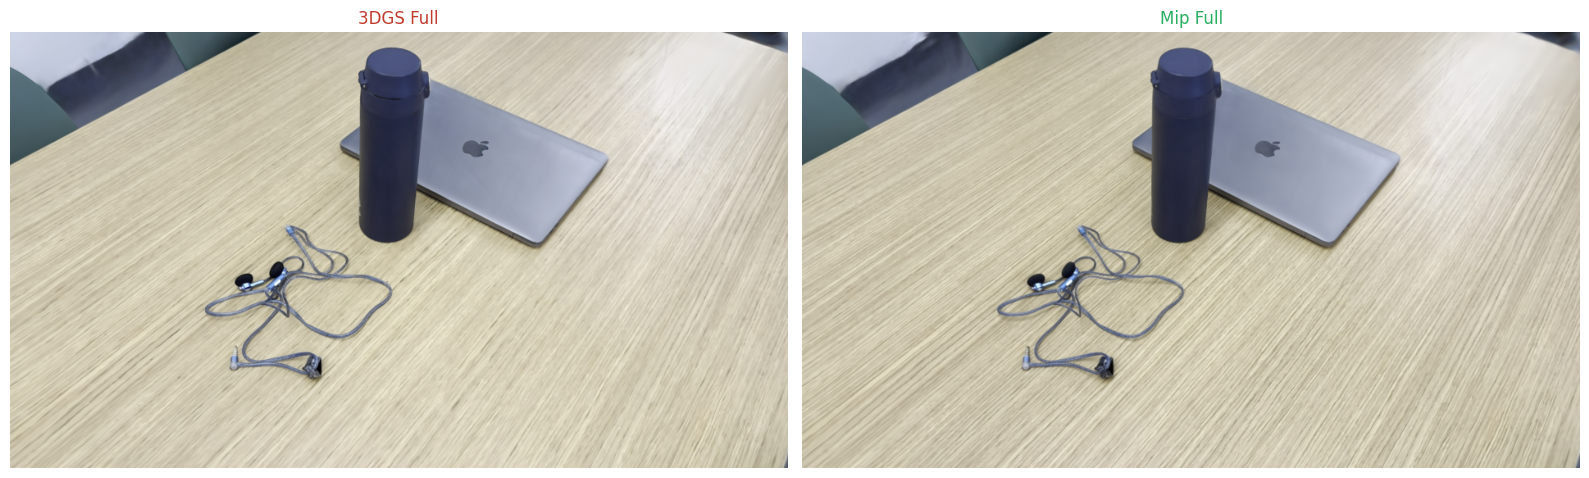

Tune CROP_BOX below then run Cell 13h


In [22]:
# -- CELL 13g: Zoom Crop - Own Scene (10k) --
from PIL import Image
import matplotlib.pyplot as plt, matplotlib.patches as patches
from glob import glob
import numpy as np, os

SCALE  = 4
FRAME  = len(sorted(glob(f'{OWN_RND_3DGS}/scale_{SCALE}x/*.png'))) // 2

imgs3 = sorted(glob(f'{OWN_RND_3DGS}/scale_{SCALE}x/*.png'))
imgsm = sorted(glob(f'{OWN_RND_MIP}/scale_{SCALE}x/*.png'))

if not imgs3:
    print('No renders - run Cell 13e first')
else:
    img3 = Image.open(imgs3[FRAME])
    imgm = Image.open(imgsm[FRAME])
    w, h = img3.size
    print(f'Image size: {w}x{h} | Frame: {FRAME}')

    # Show full frame first
    fig, axes = plt.subplots(1,2,figsize=(16,5))
    axes[0].imshow(np.array(img3)); axes[0].set_title('3DGS Full',color='#c0392b'); axes[0].axis('off')
    axes[1].imshow(np.array(imgm)); axes[1].set_title('Mip Full', color='#27ae60'); axes[1].axis('off')
    plt.tight_layout(); plt.show()
    print('Tune CROP_BOX below then run Cell 13h')


In [23]:
# -- CELL 13h: Own Scene Detail Crop --
# Tune CROP_BOX after seeing full frame above
# Good targets: earphone cables, MacBook edges, wood grain texture
CROP_BOX = (300, 300, 700, 600)   # <- tune this

from PIL import Image
import matplotlib.pyplot as plt, matplotlib.patches as patches
from glob import glob
import numpy as np, os

SCALE, FRAME = 4, len(sorted(glob(f'{OWN_RND_3DGS}/scale_4x/*.png'))) // 2
imgs3 = sorted(glob(f'{OWN_RND_3DGS}/scale_{SCALE}x/*.png'))
imgsm = sorted(glob(f'{OWN_RND_MIP}/scale_{SCALE}x/*.png'))
img3  = Image.open(imgs3[FRAME])
imgm  = Image.open(imgsm[FRAME])
c3    = np.array(img3.crop(CROP_BOX))
cm    = np.array(imgm.crop(CROP_BOX))
diff  = np.abs(c3.astype(float)-cm.astype(float))
dn    = (diff/(diff.max()+1e-8)*255).astype(np.uint8)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(
    f'{YOUR_SCENE} - Aliasing Detail | {OWN_ITERATIONS} iters | Scale 1/{SCALE}\n'
    f'Top: 3DGS | Bottom: Mip-Splatting | Right: Difference',
    fontsize=13, fontweight='bold'
)

for row, (img, arr, label, color) in enumerate([
    (img3, c3, '3DGS',         '#c0392b'),
    (imgm, cm, 'Mip-Splatting','#27ae60')
]):
    axes[row][0].imshow(np.array(img))
    axes[row][0].add_patch(patches.Rectangle(
        (CROP_BOX[0],CROP_BOX[1]),CROP_BOX[2]-CROP_BOX[0],CROP_BOX[3]-CROP_BOX[1],
        lw=3,edgecolor=color,facecolor='none'))
    axes[row][0].set_title(f'{label} Full',fontsize=10,color=color); axes[row][0].axis('off')
    axes[row][1].imshow(arr)
    axes[row][1].set_title(f'{label} Crop',fontsize=10,color=color); axes[row][1].axis('off')
    axes[row][2].imshow(dn,cmap='hot')
    axes[row][2].set_title('Difference Heatmap',fontsize=10,color='purple'); axes[row][2].axis('off')

plt.tight_layout()
out = f'{OWN_COMP_DIR}/zoom_crop_{YOUR_SCENE}_{OWN_ITERATIONS}iter_scale{SCALE}.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
print(f'OK Saved: {out}')
plt.show()


Output hidden; open in https://colab.research.google.com to view.

## CELL 14 - Output Summary

In [24]:
# -- CELL 14: Output Summary --
import os
from glob import glob

print('='*60)
print('  CS 515 - OUTPUT SUMMARY')
print('='*60)

for label, path in [
    ('3DGS Model (garden)',             MODEL_3DGS),
    ('Mip  Model (garden)',             MODEL_MIP),
    ('3DGS Renders (garden)',           RENDER_3DGS),
    ('Mip  Renders (garden)',           RENDER_MIP),
    ('Comparison (garden)',             COMPARE_DIR),
    (f'3DGS Model ({YOUR_SCENE})',      OWN_MDL_3DGS),
    (f'Mip  Model ({YOUR_SCENE})',      OWN_MDL_MIP),
    (f'3DGS Renders ({OWN_ITERATIONS}i)',OWN_RND_3DGS),
    (f'Mip  Renders ({OWN_ITERATIONS}i)',OWN_RND_MIP),
    (f'Comparison ({OWN_ITERATIONS}i)', OWN_COMP_DIR),
]:
    n = len(glob(f'{path}/**/*',recursive=True)) if os.path.exists(path) else 0
    print(f'  {"OK" if n>0 else "--"}  {label:<35} ({n} files)')
print('='*60)


  CS 515 - OUTPUT SUMMARY
  OK  3DGS Model (garden)                 (63 files)
  OK  Mip  Model (garden)                 (62 files)
  OK  3DGS Renders (garden)               (100 files)
  OK  Mip  Renders (garden)               (92 files)
  OK  Comparison (garden)                 (4 files)
  OK  3DGS Model (my_scene)               (734 files)
  OK  Mip  Model (my_scene)               (734 files)
  OK  3DGS Renders (10000i)               (358 files)
  OK  Mip  Renders (10000i)               (358 files)
  OK  Comparison (10000i)                 (3 files)


---
## CELL 15 - Convert .ply to .splat for SuperSplat Viewer

**How to view your scene:**
1. Run this cell to convert .ply to .splat format
2. Download the .splat files from Drive to your Mac
3. Open https://playcanvas.com/supersplat/editor in Chrome
4. Drag and drop the .splat file to view interactively

No GitHub/hosting needed — works locally on your Mac instantly.

In [25]:
# -- CELL 15: Convert .ply -> .splat for SuperSplat --
import os, numpy as np
from plyfile import PlyData

def ply_to_splat(ply_path, splat_path):
    print(f'  Reading {os.path.basename(ply_path)}...')
    v = PlyData.read(ply_path)['vertex']
    n = len(v['x'])
    print(f'  {n:,} Gaussians')
    xyz   = np.stack([v['x'],v['y'],v['z']], axis=1).astype(np.float32)
    scale = np.exp(np.stack([v['scale_0'],v['scale_1'],v['scale_2']], axis=1)).astype(np.float32)
    rot   = np.stack([v['rot_1'],v['rot_2'],v['rot_3'],v['rot_0']], axis=1).astype(np.float32)
    rot  /= (np.linalg.norm(rot, axis=1, keepdims=True)+1e-8)
    opac  = 1.0/(1.0+np.exp(-v['opacity'].astype(np.float32)))
    C0    = 0.28209479177387814
    r = np.clip((0.5+C0*v['f_dc_0'])*255,0,255).astype(np.uint8)
    g = np.clip((0.5+C0*v['f_dc_1'])*255,0,255).astype(np.uint8)
    b = np.clip((0.5+C0*v['f_dc_2'])*255,0,255).astype(np.uint8)
    a = np.clip(opac*255,0,255).astype(np.uint8)
    idx = np.argsort(-opac)
    with open(splat_path,'wb') as f:
        for i in idx:
            f.write(xyz[i].tobytes()); f.write(scale[i].tobytes())
            f.write(bytes([r[i],g[i],b[i],a[i]]))
            f.write(bytes([int(np.clip(rot[i,j]*128+128,0,255)) for j in range(4)]))
    print(f'  OK {os.path.basename(splat_path)} ({os.path.getsize(splat_path)/1e6:.1f} MB)\n')

SPLAT_DIR = f'{PROJECT_ROOT}/splat_files'
os.makedirs(SPLAT_DIR, exist_ok=True)

# Garden scene splats
for iters, label in [(ITERATIONS, 'garden')]:
    for model_dir, tag in [(MODEL_3DGS,'3dgs'),(MODEL_MIP,'mip')]:
        ply = f'{model_dir}/point_cloud/iteration_{iters}/point_cloud.ply'
        out = f'{SPLAT_DIR}/{label}_{tag}_{iters}iter.splat'
        if os.path.exists(ply): ply_to_splat(ply, out)
        else: print(f'MISSING {ply}')

# Own scene splats (10k)
for model_dir, tag in [(OWN_MDL_3DGS,'3dgs'),(OWN_MDL_MIP,'mip')]:
    ply = f'{model_dir}/point_cloud/iteration_{OWN_ITERATIONS}/point_cloud.ply'
    out = f'{SPLAT_DIR}/{YOUR_SCENE}_{tag}_{OWN_ITERATIONS}iter.splat'
    if os.path.exists(ply): ply_to_splat(ply, out)
    else: print(f'MISSING {ply} - run Cell 13d first')

print('All .splat files saved to:')
print(f'  {SPLAT_DIR}')
print('\nDownload from Drive and drag into:')
print('  https://playcanvas.com/supersplat/editor')


  Reading point_cloud.ply...
  2,891,179 Gaussians
  OK garden_3dgs_7000iter.splat (92.5 MB)

  Reading point_cloud.ply...
  3,071,983 Gaussians
  OK garden_mip_7000iter.splat (98.3 MB)

  Reading point_cloud.ply...
  2,598,464 Gaussians
  OK my_scene_3dgs_10000iter.splat (83.2 MB)

  Reading point_cloud.ply...
  2,597,074 Gaussians
  OK my_scene_mip_10000iter.splat (83.1 MB)

All .splat files saved to:
  /content/drive/MyDrive/CS515_Project/splat_files

Download from Drive and drag into:
  https://playcanvas.com/supersplat/editor


---
## SESSION RESUME
### Run R0 to R3 every new session

| Cell | What | Time |
|---|---|---|
| R0 | Verify GPU | 5 sec |
| R1 | Mount Drive + restore all variables | 15 sec |
| R2 | Reinstall CUDA deps | ~5 min |
| R3 | Full status check | 5 sec |

In [2]:
# -- RESUME R0: Verify GPU --
import subprocess, torch
print(subprocess.run(['nvidia-smi'], capture_output=True, text=True).stdout)
vram = torch.cuda.get_device_properties(0).total_memory/1e9 if torch.cuda.is_available() else 0
print(f'GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NONE"} | VRAM: {vram:.1f}GB')
print('A100 - RESOLUTION=1' if vram>35 else ('L4/V100 - RESOLUTION=2' if vram>20 else 'T4 - RESOLUTION=4'))


Tue Apr 28 21:17:34 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   39C    P0             54W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [3]:
# -- RESUME R1: Mount Drive + Restore All Variables --
from google.colab import drive
import os
drive.mount('/content/drive')

PROJECT_ROOT   = '/content/drive/MyDrive/CS515_Project'
SCENE          = 'garden'
ITERATIONS     = 7000
RESOLUTION     = 1      # change to 4 on T4
YOUR_SCENE     = 'my_scene'
OWN_ITERATIONS = 10000

SOURCE_DIR  = f'/content/data/{SCENE}'
MODEL_3DGS  = f'{PROJECT_ROOT}/models/3dgs_baseline/{SCENE}'
MODEL_MIP   = f'{PROJECT_ROOT}/models/mip_splatting/{SCENE}'
RENDER_3DGS = f'{PROJECT_ROOT}/renders/3dgs_baseline/{SCENE}'
RENDER_MIP  = f'{PROJECT_ROOT}/renders/mip_splatting/{SCENE}'
COMPARE_DIR = f'{PROJECT_ROOT}/renders/comparison/{SCENE}'

OWN_SCENE_DIR = f'{PROJECT_ROOT}/datasets/own_data/{YOUR_SCENE}'
OWN_INPUT_DIR = f'{OWN_SCENE_DIR}/input'
OWN_MDL_3DGS  = f'{PROJECT_ROOT}/models/3dgs_baseline/{YOUR_SCENE}'
OWN_MDL_MIP   = f'{PROJECT_ROOT}/models/mip_splatting/{YOUR_SCENE}'
OWN_RND_3DGS  = f'{PROJECT_ROOT}/renders/3dgs_baseline/{YOUR_SCENE}_{OWN_ITERATIONS}iter'
OWN_RND_MIP   = f'{PROJECT_ROOT}/renders/mip_splatting/{YOUR_SCENE}_{OWN_ITERATIONS}iter'
OWN_COMP_DIR  = f'{PROJECT_ROOT}/renders/comparison/{YOUR_SCENE}_{OWN_ITERATIONS}iter'
SPLAT_DIR     = f'{PROJECT_ROOT}/splat_files'

REPO_DIR = f'{PROJECT_ROOT}/code/gaussian-splatting'
if not os.path.exists('/content/gaussian-splatting'):
    os.symlink(REPO_DIR, '/content/gaussian-splatting')
os.makedirs('/content/data', exist_ok=True)
SCENE_DIR = f'{PROJECT_ROOT}/datasets/paper_data/{SCENE}'
if os.path.exists(SCENE_DIR) and not os.path.exists(SOURCE_DIR):
    os.symlink(SCENE_DIR, SOURCE_DIR)

print('OK All variables restored')
print(f'   Garden 3DGS     : {os.path.exists(MODEL_3DGS)}')
print(f'   Garden Mip      : {os.path.exists(MODEL_MIP)}')
print(f'   Own 3DGS (10k)  : {os.path.exists(OWN_MDL_3DGS)}')
print(f'   Own Mip  (10k)  : {os.path.exists(OWN_MDL_MIP)}')


Mounted at /content/drive
OK All variables restored
   Garden 3DGS     : True
   Garden Mip      : True
   Own 3DGS (10k)  : True
   Own Mip  (10k)  : True


In [4]:
# -- RESUME R2: Reinstall CUDA deps from local copy --
import os
os.chdir('/content')
if not os.path.exists('/content/submodules'):
    !cp -r /content/gaussian-splatting/submodules /content/submodules
!pip install /content/submodules/diff-gaussian-rasterization -q
!pip install /content/submodules/simple-knn -q
!pip install plyfile tqdm -q
import torch
try:
    from diff_gaussian_rasterization import GaussianRasterizer
    from simple_knn._C import distCUDA2
    print(f'OK All packages ready | {torch.__version__} | CUDA {torch.version.cuda}')
except ImportError as e:
    print(f'FAILED: {e} - re-run this cell')


^C
ERROR: Directory '/content/submodules/diff-gaussian-rasterization' is not installable. Neither 'setup.py' nor 'pyproject.toml' found.
ERROR: Invalid requirement: '/content/submodules/simple-knn': Expected package name at the start of dependency specifier
    /content/submodules/simple-knn
    ^
Hint: It looks like a path. File '/content/submodules/simple-knn' does not exist.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 4.1 MB/s eta 0:00:00
FAILED: No module named 'diff_gaussian_rasterization' - re-run this cell


In [5]:
# -- RESUME R3: Full Status Check --
import os
from glob import glob

def chk(label, path):
    n = len(glob(f'{path}/**/*',recursive=True)) if os.path.exists(path) else 0
    print(f'  {"OK" if n>0 else "--"} {label:<38} ({n} files)')

print('-- Garden Scene (7k) -------------------------------------')
chk('3DGS .ply',    f'{MODEL_3DGS}/point_cloud/iteration_{ITERATIONS}')
chk('Mip  .ply',    f'{MODEL_MIP}/point_cloud/iteration_{ITERATIONS}')
chk('3DGS renders', RENDER_3DGS)
chk('Mip  renders', RENDER_MIP)
chk('Comparison',   COMPARE_DIR)

print(f'-- Own Scene ({YOUR_SCENE} 10k) ----------------------')
chk('3DGS .ply',    f'{OWN_MDL_3DGS}/point_cloud/iteration_{OWN_ITERATIONS}')
chk('Mip  .ply',    f'{OWN_MDL_MIP}/point_cloud/iteration_{OWN_ITERATIONS}')
chk('3DGS renders', OWN_RND_3DGS)
chk('Mip  renders', OWN_RND_MIP)
chk('Comparison',   OWN_COMP_DIR)

print('-- Splat Files -------------------------------------------')
chk('Splat files',  SPLAT_DIR)
print('----------------------------------------------------------')


-- Garden Scene (7k) -------------------------------------
  OK 3DGS .ply                              (1 files)
  OK Mip  .ply                              (1 files)
  OK 3DGS renders                           (100 files)
  OK Mip  renders                           (92 files)
  OK Comparison                             (4 files)
-- Own Scene (my_scene 10k) ----------------------
  OK 3DGS .ply                              (1 files)
  OK Mip  .ply                              (1 files)
  OK 3DGS renders                           (358 files)
  OK Mip  renders                           (358 files)
  OK Comparison                             (3 files)
-- Splat Files -------------------------------------------
  OK Splat files                            (4 files)
----------------------------------------------------------


In [6]:
# -- Separate 3DGS and Mip-Splatting output folders ---------------------------
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from glob import glob
import os

# Output directories
OUT_3DGS = f'{PROJECT_ROOT}/renders/OUTPUT_3DGS'
OUT_MIP  = f'{PROJECT_ROOT}/renders/OUTPUT_MIP'
os.makedirs(OUT_3DGS, exist_ok=True)
os.makedirs(OUT_MIP,  exist_ok=True)

SCALES = [2, 4, 8]
N      = 6   # frames per scale

for scale in SCALES:
    imgs3 = sorted(glob(f'{RENDER_3DGS}/scale_{scale}x/*.png'))
    imgsm = sorted(glob(f'{RENDER_MIP}/scale_{scale}x/*.png'))

    if not imgs3:
        print(f'No renders at scale {scale}x — run Cells 8 & 9 first')
        continue

    # Pick evenly spaced frames
    idxs = [len(imgs3)*i//N for i in range(N)]

    # ── 3DGS figure ────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, N, figsize=(N*4, 4))
    fig.suptitle(
        f'3DGS Baseline — {SCENE.title()} Scene | Scale 1/{scale} | {ITERATIONS} iters\n'
        f'(Obtained by running authors code on MipNeRF360 dataset)',
        fontsize=11, fontweight='bold'
    )
    for col, idx in enumerate(idxs):
        axes[col].imshow(mpimg.imread(imgs3[idx]))
        axes[col].set_title(f'Frame {idx}', fontsize=8, color='#c0392b')
        axes[col].axis('off')
    plt.tight_layout()
    out = f'{OUT_3DGS}/3dgs_{SCENE}_scale{scale}x_{ITERATIONS}iter.png'
    plt.savefig(out, dpi=150, bbox_inches='tight')
    print(f'OK 3DGS: {out}')
    plt.show()

    # ── Mip-Splatting figure ───────────────────────────────────────────────────
    fig, axes = plt.subplots(1, N, figsize=(N*4, 4))
    fig.suptitle(
        f'Mip-Splatting — {SCENE.title()} Scene | Scale 1/{scale} | {ITERATIONS} iters\n'
        f'(Obtained by running authors code on MipNeRF360 dataset)',
        fontsize=11, fontweight='bold'
    )
    for col, idx in enumerate(idxs):
        axes[col].imshow(mpimg.imread(imgsm[idx]))
        axes[col].set_title(f'Frame {idx}', fontsize=8, color='#27ae60')
        axes[col].axis('off')
    plt.tight_layout()
    out = f'{OUT_MIP}/mip_{SCENE}_scale{scale}x_{ITERATIONS}iter.png'
    plt.savefig(out, dpi=150, bbox_inches='tight')
    print(f'OK Mip:  {out}')
    plt.show()

# ── Same for own scene ─────────────────────────────────────────────────────────
OWN_OUT_3DGS = f'{PROJECT_ROOT}/renders/OUTPUT_3DGS/own_scene'
OWN_OUT_MIP  = f'{PROJECT_ROOT}/renders/OUTPUT_MIP/own_scene'
os.makedirs(OWN_OUT_3DGS, exist_ok=True)
os.makedirs(OWN_OUT_MIP,  exist_ok=True)

for scale in [4, 8]:
    imgs3 = sorted(glob(f'{OWN_RND_3DGS}/scale_{scale}x/*.png'))
    imgsm = sorted(glob(f'{OWN_RND_MIP}/scale_{scale}x/*.png'))

    if not imgs3:
        print(f'Own scene: no renders at scale {scale}x — run Cell 13e first')
        continue

    idxs = [len(imgs3)*i//N for i in range(N)]

    for renders, out_dir, label, color, prefix in [
        (imgs3, OWN_OUT_3DGS, '3DGS Baseline',  '#c0392b', '3dgs'),
        (imgsm, OWN_OUT_MIP,  'Mip-Splatting',  '#27ae60', 'mip'),
    ]:
        fig, axes = plt.subplots(1, N, figsize=(N*4, 4))
        fig.suptitle(
            f'{label} — Own Scene ({YOUR_SCENE}) | Scale 1/{scale} | {OWN_ITERATIONS} iters\n'
            f'(Obtained by running authors code on images from own phone camera)',
            fontsize=11, fontweight='bold'
        )
        for col, idx in enumerate(idxs):
            axes[col].imshow(mpimg.imread(renders[idx]))
            axes[col].set_title(f'Frame {idx}', fontsize=8, color=color)
            axes[col].axis('off')
        plt.tight_layout()
        out = f'{out_dir}/{prefix}_{YOUR_SCENE}_scale{scale}x_{OWN_ITERATIONS}iter.png'
        plt.savefig(out, dpi=150, bbox_inches='tight')
        print(f'OK {label}: {out}')
        plt.show()

print('\nDone! Check Drive at:')
print(f'  {OUT_3DGS}')
print(f'  {OUT_MIP}')

Output hidden; open in https://colab.research.google.com to view.

In [6]:
# -- Render video from rendered frames -----------------------------------------
import os, subprocess

def frames_to_video(frames_dir, output_path, fps=24):
    frames = sorted([f for f in os.listdir(frames_dir) if f.endswith('.png')])
    if not frames:
        print(f'No frames in {frames_dir}')
        return
    print(f'  {len(frames)} frames -> {output_path}')

    !ffmpeg -y \
        -framerate {fps} \
        -pattern_type glob \
        -i '{frames_dir}/*.png' \
        -c:v libx264 \
        -pix_fmt yuv420p \
        -crf 18 \
        {output_path} \
        -hide_banner -loglevel error

    if os.path.exists(output_path):
        print(f'  OK ({os.path.getsize(output_path)/1e6:.1f} MB)')
    else:
        print(f'  FAILED')

VIDEO_DIR = f'{PROJECT_ROOT}/renders/videos'
os.makedirs(VIDEO_DIR, exist_ok=True)

# Garden scene videos
for scale in [2, 4, 8]:
    dir3 = f'{RENDER_3DGS}/scale_{scale}x'
    dirm = f'{RENDER_MIP}/scale_{scale}x'

    print(f'\nScale 1/{scale}:')
    frames_to_video(dir3, f'{VIDEO_DIR}/3dgs_{SCENE}_scale{scale}x_{ITERATIONS}iter.mp4')
    frames_to_video(dirm, f'{VIDEO_DIR}/mip_{SCENE}_scale{scale}x_{ITERATIONS}iter.mp4')

# Own scene videos
for scale in [4, 8]:
    dir3 = f'{OWN_RND_3DGS}/scale_{scale}x'
    dirm = f'{OWN_RND_MIP}/scale_{scale}x'

    print(f'\nOwn scene scale 1/{scale}:')
    frames_to_video(dir3, f'{VIDEO_DIR}/3dgs_{YOUR_SCENE}_scale{scale}x_{OWN_ITERATIONS}iter.mp4')
    frames_to_video(dirm, f'{VIDEO_DIR}/mip_{YOUR_SCENE}_scale{scale}x_{OWN_ITERATIONS}iter.mp4')

print(f'\nAll videos saved to: {VIDEO_DIR}')
print('Download from Drive for presentation/report')


Scale 1/2:
  24 frames -> /content/drive/MyDrive/CS515_Project/renders/videos/3dgs_garden_scale2x_7000iter.mp4
  OK (9.6 MB)
  24 frames -> /content/drive/MyDrive/CS515_Project/renders/videos/mip_garden_scale2x_7000iter.mp4
  OK (12.7 MB)

Scale 1/4:
  24 frames -> /content/drive/MyDrive/CS515_Project/renders/videos/3dgs_garden_scale4x_7000iter.mp4
[libx264 @ 0x58276b0fd900] width not divisible by 2 (1297x840)
Error initializing output stream 0:0 -- Error while opening encoder for output stream #0:0 - maybe incorrect parameters such as bit_rate, rate, width or height
  OK (0.0 MB)
  24 frames -> /content/drive/MyDrive/CS515_Project/renders/videos/mip_garden_scale4x_7000iter.mp4
[libx264 @ 0x59809142a900] width not divisible by 2 (1297x840)
Error initializing output stream 0:0 -- Error while opening encoder for output stream #0:0 - maybe incorrect parameters such as bit_rate, rate, width or height
  OK (0.0 MB)

Scale 1/8:
  24 frames -> /content/drive/MyDrive/CS515_Project/renders/vid

In [7]:
# -- Fix: render videos with dimension padding for odd sizes ------------------
import os

def frames_to_video(frames_dir, output_path, fps=24):
    frames = sorted([f for f in os.listdir(frames_dir) if f.endswith('.png')])
    if not frames:
        print(f'  No frames in {frames_dir}'); return
    print(f'  {len(frames)} frames -> {output_path}')

    # vf "pad" rounds width and height up to nearest even number
    !ffmpeg -y \
        -framerate {fps} \
        -pattern_type glob \
        -i '{frames_dir}/*.png' \
        -vf "pad=ceil(iw/2)*2:ceil(ih/2)*2" \
        -c:v libx264 \
        -pix_fmt yuv420p \
        -crf 18 \
        {output_path} \
        -hide_banner -loglevel error

    if os.path.exists(output_path) and os.path.getsize(output_path) > 0:
        print(f'  OK ({os.path.getsize(output_path)/1e6:.1f} MB)')
    else:
        print(f'  FAILED')

VIDEO_DIR = f'{PROJECT_ROOT}/renders/videos'

# Re-render only the failed scale 4x videos
print('Re-rendering scale 4x (failed ones):')
for dir_path, out_name in [
    (f'{RENDER_3DGS}/scale_4x', f'3dgs_{SCENE}_scale4x_{ITERATIONS}iter.mp4'),
    (f'{RENDER_MIP}/scale_4x',  f'mip_{SCENE}_scale4x_{ITERATIONS}iter.mp4'),
    (f'{OWN_RND_3DGS}/scale_4x', f'3dgs_{YOUR_SCENE}_scale4x_{OWN_ITERATIONS}iter.mp4'),
    (f'{OWN_RND_MIP}/scale_4x',  f'mip_{YOUR_SCENE}_scale4x_{OWN_ITERATIONS}iter.mp4'),
]:
    frames_to_video(dir_path, f'{VIDEO_DIR}/{out_name}')

print('\nDone!')

Re-rendering scale 4x (failed ones):
  24 frames -> /content/drive/MyDrive/CS515_Project/renders/videos/3dgs_garden_scale4x_7000iter.mp4
  OK (3.9 MB)
  24 frames -> /content/drive/MyDrive/CS515_Project/renders/videos/mip_garden_scale4x_7000iter.mp4
  OK (4.4 MB)
  178 frames -> /content/drive/MyDrive/CS515_Project/renders/videos/3dgs_my_scene_scale4x_10000iter.mp4
  OK (3.5 MB)
  178 frames -> /content/drive/MyDrive/CS515_Project/renders/videos/mip_my_scene_scale4x_10000iter.mp4
  OK (3.8 MB)

Done!


Total frames: 178
Using frame: 97
Image size: 474x266
OK /content/drive/MyDrive/CS515_Project/renders/comparison/my_scene_10000iter/frame97_scale8x_fullframe.png


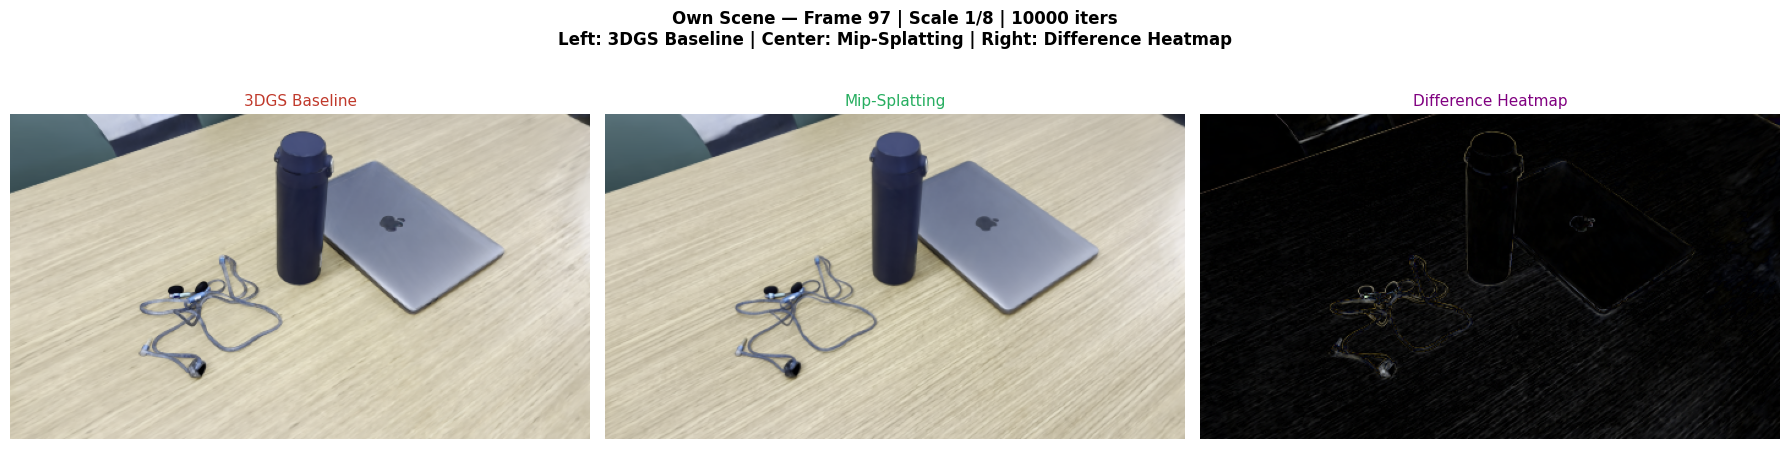


Crop box: (118, 66, 355, 199) — adjust and re-run if needed
OK /content/drive/MyDrive/CS515_Project/renders/comparison/my_scene_10000iter/frame97_scale8x_crop.png


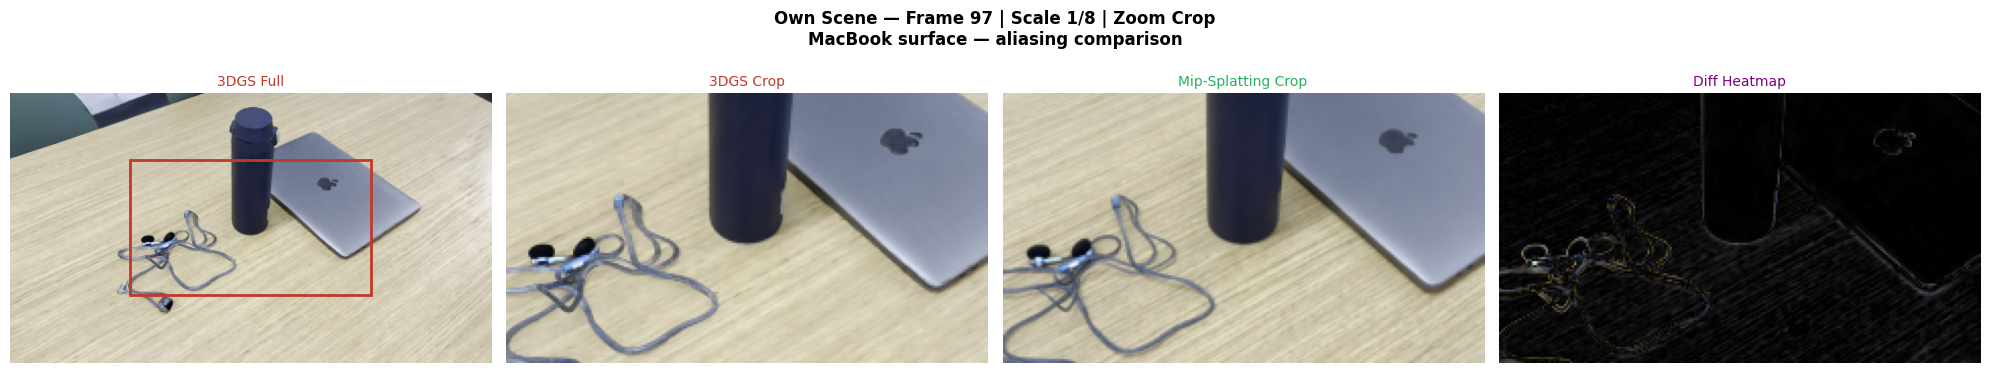

In [10]:
# -- Compare frame 97 at scale 8x: 3DGS vs Mip-Splatting ----------------------
from PIL import Image
import matplotlib.pyplot as plt, matplotlib.patches as patches
import numpy as np, os
from glob import glob

SCALE = 8
FRAME = 97

imgs3 = sorted(glob(f'{OWN_RND_3DGS}/scale_{SCALE}x/*.png'))
imgsm = sorted(glob(f'{OWN_RND_MIP}/scale_{SCALE}x/*.png'))

print(f'Total frames: {len(imgs3)}')
print(f'Using frame: {FRAME}')

img3 = Image.open(imgs3[FRAME])
imgm = Image.open(imgsm[FRAME])
w, h = img3.size
print(f'Image size: {w}x{h}')

arr3 = np.array(img3)
arrm = np.array(imgm)
diff = np.abs(arr3.astype(float) - arrm.astype(float))
diff_norm = (diff / (diff.max() + 1e-8) * 255).astype(np.uint8)

# ── Full frame comparison ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    f'Own Scene — Frame {FRAME} | Scale 1/{SCALE} | {OWN_ITERATIONS} iters\n'
    f'Left: 3DGS Baseline | Center: Mip-Splatting | Right: Difference Heatmap',
    fontsize=12, fontweight='bold'
)
axes[0].imshow(arr3);       axes[0].set_title('3DGS Baseline', fontsize=11, color='#c0392b'); axes[0].axis('off')
axes[1].imshow(arrm);       axes[1].set_title('Mip-Splatting', fontsize=11, color='#27ae60'); axes[1].axis('off')
axes[2].imshow(diff_norm, cmap='hot'); axes[2].set_title('Difference Heatmap', fontsize=11, color='purple'); axes[2].axis('off')

plt.tight_layout()
out = f'{OWN_COMP_DIR}/frame{FRAME}_scale{SCALE}x_fullframe.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
print(f'OK {out}')
plt.show()

# ── Zoom into MacBook area ─────────────────────────────────────────────────────
# Adjust CROP_BOX to the MacBook logo/edges area
CROP_BOX = (w//4, h//4, 3*w//4, 3*h//4)  # center crop — tune after seeing full frame
print(f'\nCrop box: {CROP_BOX} — adjust and re-run if needed')

c3   = np.array(img3.crop(CROP_BOX))
cm   = np.array(imgm.crop(CROP_BOX))
cdiff = np.abs(c3.astype(float) - cm.astype(float))
cdn   = (cdiff / (cdiff.max() + 1e-8) * 255).astype(np.uint8)

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
fig.suptitle(
    f'Own Scene — Frame {FRAME} | Scale 1/{SCALE} | Zoom Crop\n'
    f'MacBook surface — aliasing comparison',
    fontsize=12, fontweight='bold'
)

# 3DGS full + crop box
axes[0].imshow(arr3)
axes[0].add_patch(patches.Rectangle(
    (CROP_BOX[0], CROP_BOX[1]),
    CROP_BOX[2]-CROP_BOX[0], CROP_BOX[3]-CROP_BOX[1],
    lw=2, edgecolor='#c0392b', facecolor='none'))
axes[0].set_title('3DGS Full', fontsize=10, color='#c0392b'); axes[0].axis('off')

axes[1].imshow(c3);   axes[1].set_title('3DGS Crop',          fontsize=10, color='#c0392b'); axes[1].axis('off')
axes[2].imshow(cm);   axes[2].set_title('Mip-Splatting Crop', fontsize=10, color='#27ae60'); axes[2].axis('off')
axes[3].imshow(cdn, cmap='hot'); axes[3].set_title('Diff Heatmap', fontsize=10, color='purple'); axes[3].axis('off')

plt.tight_layout()
out2 = f'{OWN_COMP_DIR}/frame{FRAME}_scale{SCALE}x_crop.png'
plt.savefig(out2, dpi=150, bbox_inches='tight')
print(f'OK {out2}')
plt.show()